In [318]:
import numpy as np 
import polars as pl 
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [371]:
df = pl.scan_csv(r'C:\Users\erics\courses\gradml1\crypto_pred_market\data_gather\final_data\final_data.csv').collect()
df = df.filter(pl.col('time_to_close').is_between(0,300))

In [372]:
df.shape

(350163, 54)

In [373]:
np.median(df['yes_mid_dollars'])



np.float64(0.495)

In [374]:
def _to_datetime(table: pl.DataFrame, cols: list) -> pl.DataFrame:
        for col in cols: 
            table = table.with_columns(
                pl.col(col)
                .str.to_datetime(format="%Y-%m-%dT%H:%M:%S%.f%#z", strict=False)
                .alias(col)
            )
        return table

df = _to_datetime(df, cols = ['curr_time', 'open_time', 'close_time', 'prev_time'])


In [375]:
event_col_ids = ['open_time', 'close_time']
event_ids = (df.select(event_col_ids).unique().sort('open_time'))
n = 0.7

X_train_ids = event_ids[:round(n*len(event_ids))]
X_test_ids = event_ids[round(n*len(event_ids)):]

y_train = df.join(X_train_ids, on=event_col_ids, how = 'inner').select('outcome')
X_train = df.join(X_train_ids, on=event_col_ids, how = 'inner').drop('curr_time', 'outcome', 'open_time', 'close_time', 'prev_time', 'next_price_dollars_lead1')

y_test = df.join(X_test_ids, on=event_col_ids, how = 'inner').select('outcome')
X_test = df.join(X_test_ids, on=event_col_ids, how = 'inner').drop('curr_time', 'outcome', 'open_time', 'close_time', 'prev_time', 'next_price_dollars_lead1')



In [409]:
from sklearn.model_selection import GroupShuffleSplit

groups = df['open_time'].cast(str) + '_' + df['close_time'].cast(str)

gss = GroupShuffleSplit(n_splits=1, test_size=0.1)
train_idx, test_idx = next(gss.split(df, groups=groups.to_numpy()))

drop_cols = ['curr_time', 'outcome', 'open_time', 'close_time', 'prev_time', 'next_price_dollars_lead1']

X_train = df[train_idx].drop(drop_cols)
y_train = df[train_idx].select('outcome')
X_test = df[test_idx].drop(drop_cols)
y_test = df[test_idx].select('outcome')

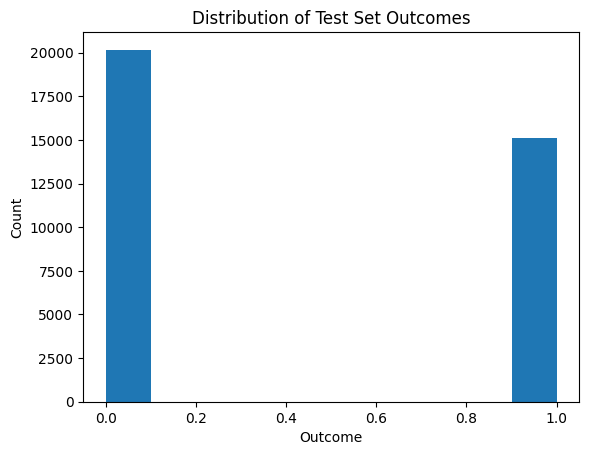

In [410]:
import matplotlib.pyplot as plt 
plt.hist(y_test)
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Distribution of Test Set Outcomes')
plt.show()

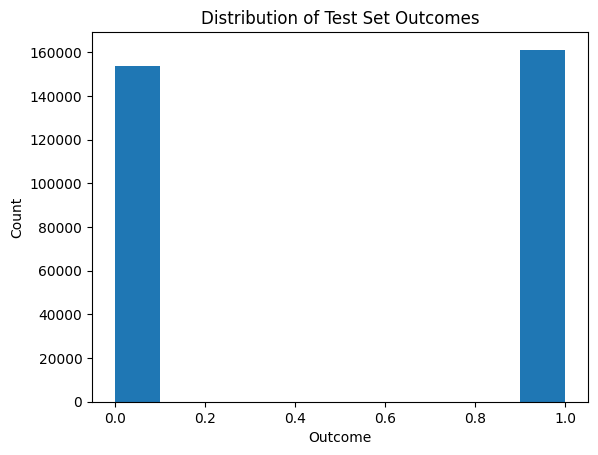

In [411]:
import matplotlib.pyplot as plt 
plt.hist(y_train)
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Distribution of Test Set Outcomes')
plt.show()

In [412]:
log_reg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
log_reg.fit(X_train.to_numpy(), y_train.to_numpy().ravel())

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

In [413]:
log_reg.score(X_test.to_numpy(), y_test.to_numpy().ravel())
y_pred = log_reg.predict(X_test.to_numpy())
print("Accuracy:", accuracy_score(y_test.to_numpy().ravel(), y_pred))
print(confusion_matrix(y_test.to_numpy().ravel(), y_pred))
print(classification_report(y_test.to_numpy().ravel(), y_pred))

Accuracy: 0.8841968030835506
[[17952  2215]
 [ 1871 13246]]
              precision    recall  f1-score   support

           0       0.91      0.89      0.90     20167
           1       0.86      0.88      0.87     15117

    accuracy                           0.88     35284
   macro avg       0.88      0.88      0.88     35284
weighted avg       0.88      0.88      0.88     35284



In [414]:
# probability of class 1 p_hat := [class0_prob, class1_prob]
p_hat = log_reg.predict_proba(X_test.to_numpy())[:,-1]
q = df[test_idx].select('yes_mid_dollars').to_numpy().ravel()

p_hat - q

ev_yes = p_hat - q 
ev_no = q-p_hat

threshold = 0.1 
ev_yes

array([-0.00062253, -0.00077372, -0.00167234, ..., -0.3254718 ,
       -0.33033642, -0.329476  ], shape=(35284,))

In [453]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import GroupShuffleSplit

groups = df['open_time'].cast(str) + '_' + df['close_time'].cast(str)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2)
train_idx, test_idx = next(gss.split(df, groups=groups.to_numpy()))

drop_cols = ['curr_time', 'outcome', 'open_time', 'close_time', 'prev_time', 'next_price_dollars_lead1']

X_train = df[train_idx].drop(drop_cols)
y_train = df[train_idx].select('outcome')
X_test = df[test_idx].drop(drop_cols)
y_test = df[test_idx].select('outcome')


X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy().ravel()
X_test_np = X_test.to_numpy()
y_test_np = y_test.to_numpy().ravel()

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=10000)
)

model.fit(X_train_np, y_train_np)

p_hat = model.predict_proba(X_test_np)[:, 1]
q = X_test["yes_mid_dollars"].to_numpy().ravel()

ev_yes = p_hat - q
ev_no = q - p_hat

threshold = 0.1

position = np.zeros(len(q))
position[ev_yes > threshold] = 1
position[ev_no > threshold] = -1
print(ev_yes > threshold)
print(position)
pnl = np.zeros(len(q))

yes_mask = position == 1
pnl[yes_mask] = np.where(
    y_test_np[yes_mask] == 1,
    1 - q[yes_mask],
    -q[yes_mask]
)

no_mask = position == -1
pnl[no_mask] = np.where(
    y_test_np[no_mask] == 0,
    q[no_mask],
    -(1 - q[no_mask])
)

trade_ev = np.where(position == 1, ev_yes, np.where(position == -1, ev_no, np.nan))
trade_mask = position != 0

print("Number of trades:", trade_mask.sum())
print("Average EV of trades:", np.nanmean(trade_ev))
print("Average PnL per trade:", pnl[trade_mask].mean())
print("Total PnL:", pnl[trade_mask].sum())
print("Win rate:", (pnl[trade_mask] > 0).mean())
print("Worst trade:", pnl[trade_mask].min())
print("5th percentile PnL:", np.quantile(pnl[trade_mask], 0.05))


[False False False ...  True  True  True]
[0. 0. 0. ... 1. 1. 1.]
Number of trades: 15246
Average EV of trades: 0.18902456544727497
Average PnL per trade: 0.09236009445100353
Total PnL: 1408.1219999999998
Win rate: 0.6566968385150204
Worst trade: -0.87
5th percentile PnL: -0.675
